In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import GradientBoostingClassifier
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score
from scipy.stats import mode
from sklearn.svm import SVC

In [2]:
import sys
sys.path.append("/Users/mariahloehr/IICD/IICD/feature_importance")

In [3]:
import locomp
from locomp import *
from locomp.MLmodels import *
from locomp.util_locomp import *
import itertools
import importlib
from sklearn.base import BaseEstimator, RegressorMixin, clone
import itertools
from functools import partial
import multiprocessing as mp
import re

import functions_case as il
import importlib

import functions_tertiary as il3

In [4]:
# Load data
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/T47D.csv")

from sklearn.preprocessing import LabelEncoder

le = LabelEncoder()

# Separate features and target
X = df.drop(columns=['phase'])
y = le.fit_transform(df['phase'])
perturbation_col = X.columns.get_loc("Metadata_well")

feature_names = X.columns.tolist()
feature_pairs = list(itertools.combinations(range(X.shape[1]), 2))
feature_triplets = list(itertools.combinations(range(X.shape[1]), 3))
X = X.to_numpy()
#y = y.to_numpy()

# Split data into train and test sets (80:20)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=949, stratify=y)

In [6]:
DecisionTreeClass = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 )

In [7]:
xgbclass = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    )

In [8]:
# Define RBF-kernel SVM
svmclass = svm_model = SVC(
    kernel='rbf',
    C=1.0,              
    gamma='scale',
    probability=True,
    random_state=949
)

In [9]:
J1 = 0
J2 = 1
m_ratio = 0.2
n_ratio = 0.2
B = 10
models = (DecisionTreeClass, xgbclass, svmclass)
perturbation_col = perturbation_col

In [12]:
def get_mp_metric(X, Y, n_ratio, m_ratio, B,
                   models, perturbation_col):
    """
    Computes interaction metrics (iLOCO) for multiple feature pairs using an ensemble model.

    Parameters:
    X (numpy.ndarray): Feature matrix.
    Y (numpy.ndarray): Target variable.
    n_ratio (float): Ratio parameter for ensemble fitting.
    m_ratio (float): Ratio parameter for ensemble fitting.
    B (int): Number of bootstrap samples.
    model (object): Trained model for interaction computation.
    feature_pairs (list of tuples): List of tuples where each tuple contains two feature indices (j1, j2) for the feature pair.

    Returns:
    dict: Dictionary where keys are feature pairs (j1, j2) and values are dictionaries containing:
          - 'iloco': The mean interaction value.
          - 'iloco_max': The maximum interaction value, ensuring non-negative.
          - 'iloco_ratio': The ratio of iloco to the mean of r.
    """
    # Create and fit an ensemble model
    ensemble = il.Ensemble(models).fit(X, Y, n_ratio, m_ratio, B, perturbation_col = perturbation_col)

    # Compute feature interactions for the given list of feature pairs
    result = il.mp_and_featureInteractions_class(X, Y, n_ratio, m_ratio, B, models, 
                                                 feature_pairs, perturbation_col, bonferroni=True)

    return result

In [14]:
mp_results = []
mp_ci = []
mp_results = get_mp_metric(X, y, n_ratio, m_ratio, B, models, perturbation_col=perturbation_col)
mp_scores = [mp_results[(j, k)]['iloco'] for (j, k) in feature_pairs]
mp_ci = [mp_results[(j, k)]["ci"] for (j, k) in feature_pairs]

WITH CSV

In [3]:
df = pd.read_csv("/Users/mariahloehr/IICD/IICD/Cancer treatment/LOCO/cancer_iloco_ensemble.csv")

In [4]:
import re

def rename_feature(name):
    if "Intensity_MedianIntensity_" in name:
        return name.replace("Intensity_MedianIntensity_", "")
    
    if "Intensity_IntegratedIntensity_" in name:
        return name.replace("Intensity_IntegratedIntensity_", "")
    
    return name

# Apply renaming
renamed_features = [rename_feature(col) for col in df["feature"]]

In [5]:
df["feature"] = renamed_features

In [6]:
top_20 = df.nlargest(10, "scores")

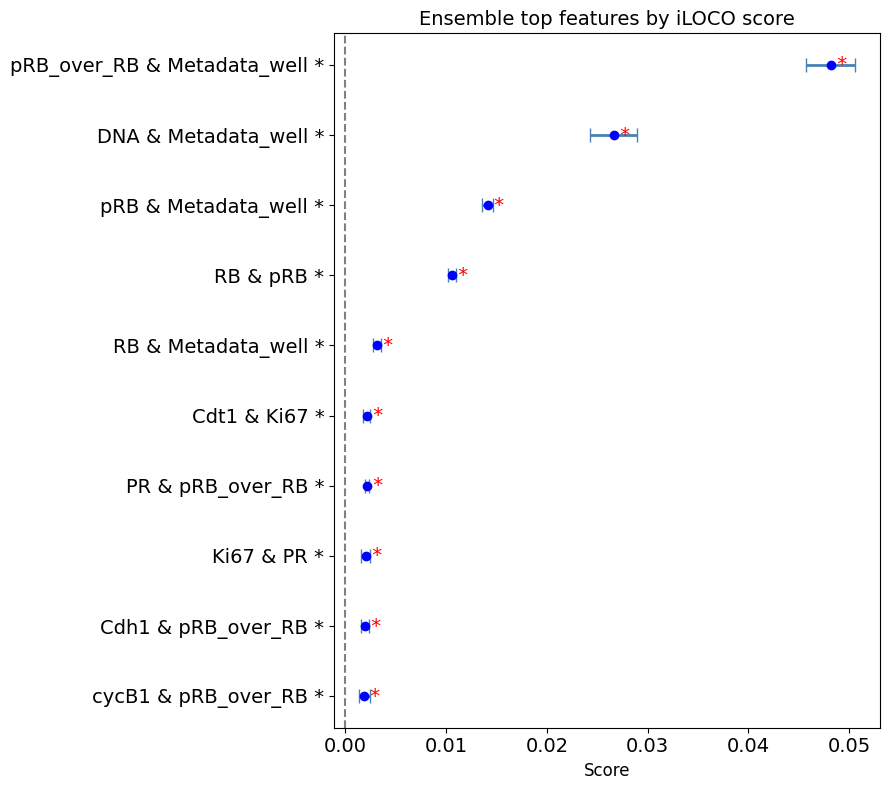

In [8]:
# Plot
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Ensemble top features by iLOCO score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()

In [9]:
df["feature"] = renamed_features
bottom = df.nsmallest(10, "scores")

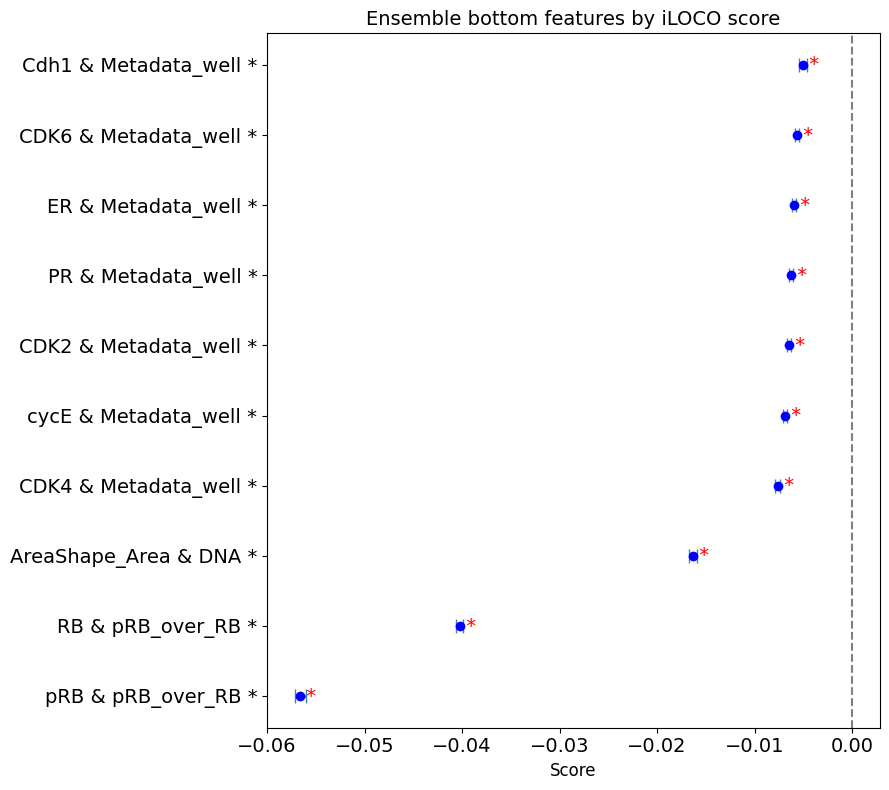

In [10]:
# Plot
ytick_labels = bottom["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(bottom["scores"], bottom["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    bottom["scores"],
    bottom["feature"],
    xerr=bottom["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(bottom["scores"], bottom["ci"], bottom["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.axvline(x=0, color='gray', linestyle='--')
plt.yticks(ticks=bottom["feature"], labels=ytick_labels, fontsize=14)
plt.xticks(fontsize=14)  
plt.xlabel("Score", fontsize=12)
plt.title("Ensemble bottom features by iLOCO score", fontsize=14)
plt.tight_layout()  # Ensure everything fits nicely
plt.show()

THIRD ORDER

In [10]:
def get_mp_metric(X, Y, n_ratio, m_ratio, B, 
                   models, feature_triplets, perturbation_col, bonferroni = False):
    """
    Computes interaction metrics (iLOCO) for multiple feature pairs using an ensemble model.

    Parameters:
    X (numpy.ndarray): Feature matrix.
    Y (numpy.ndarray): Target variable.
    n_ratio (float): Ratio parameter for ensemble fitting.
    m_ratio (float): Ratio parameter for ensemble fitting.
    B (int): Number of bootstrap samples.
    model (object): Trained model for interaction computation.
    feature_pairs (list of tuples): List of tuples where each tuple contains two feature indices (j1, j2) for the feature pair.

    Returns:
    dict: Dictionary where keys are feature pairs (j1, j2) and values are dictionaries containing:
          - 'iloco': The mean interaction value.
          - 'iloco_max': The maximum interaction value, ensuring non-negative.
          - 'iloco_ratio': The ratio of iloco to the mean of r.
    """
    # Create and fit an ensemble model
    ensemble = il3.Ensemble(models).fit(X, Y, n_ratio, m_ratio, B, perturbation_col)

    # Compute feature interactions for the given list of feature pairs
    result = il3.featureInteractions(X, Y, n_ratio, m_ratio, B,
                                    models, feature_triplets, perturbation_col, bonferroni)

    return result

In [11]:
DecisionTreeClass = DecisionTreeClassifier(max_depth = 50, 
                                 max_features=10,
                                 random_state=949
                                 )

In [12]:
xgbclass = GradientBoostingClassifier(
        n_estimators=10,       # fixed boosting rounds
        learning_rate=0.1, # hyperparameters from XGB model
        max_depth=7,
        random_state=949
    )

In [13]:
# Define RBF-kernel SVM
svmclass = svm_model = SVC(
    kernel='rbf',
    C=1.0,              
    gamma='scale',
    probability=True,
    random_state=949
)

In [14]:
J1 = 0
J2 = 1
m_ratio = 0.2
n_ratio = 0.2
B = 10
models = (DecisionTreeClass, xgbclass, svmclass)
perturbation_col = perturbation_col

In [15]:
mp3_results = []
mp3_ci = []
mp3_results = get_mp_metric(X, y, n_ratio, m_ratio, B, models = models, feature_triplets=feature_triplets, 
                            perturbation_col=perturbation_col,bonferroni= True)
mp3_scores = [mp3_results[(i, j, k)]['iloco'] for (i, j, k) in feature_triplets]
mp3_ci = [mp3_results[(i, j, k)]["ci"] for (i, j, k) in feature_triplets]

# Generate all pairwise combinations
pairwise_names = list(itertools.combinations(feature_names, 3))
# Convert each tuple to a single string
pairwise_names_str = [' & '.join(pair) for pair in pairwise_names]
data = {'feature': pairwise_names_str, 'scores': mp3_scores, 'ci': mp3_ci }
df = pd.DataFrame(data)

#df.to_csv("cancer_iloco_decisionTree.csv", index=False)

AttributeError: 'Ensemble' object has no attribute 'models'

/var/folders/1s/bvxr71hj0hqgyk_jk6k7wkm80000gn/T/ipykernel_35230/780215557.py:40: UserWarning: Tight layout not applied. The left and right margins cannot be made large enough to accommodate all Axes decorations.
  plt.tight_layout()


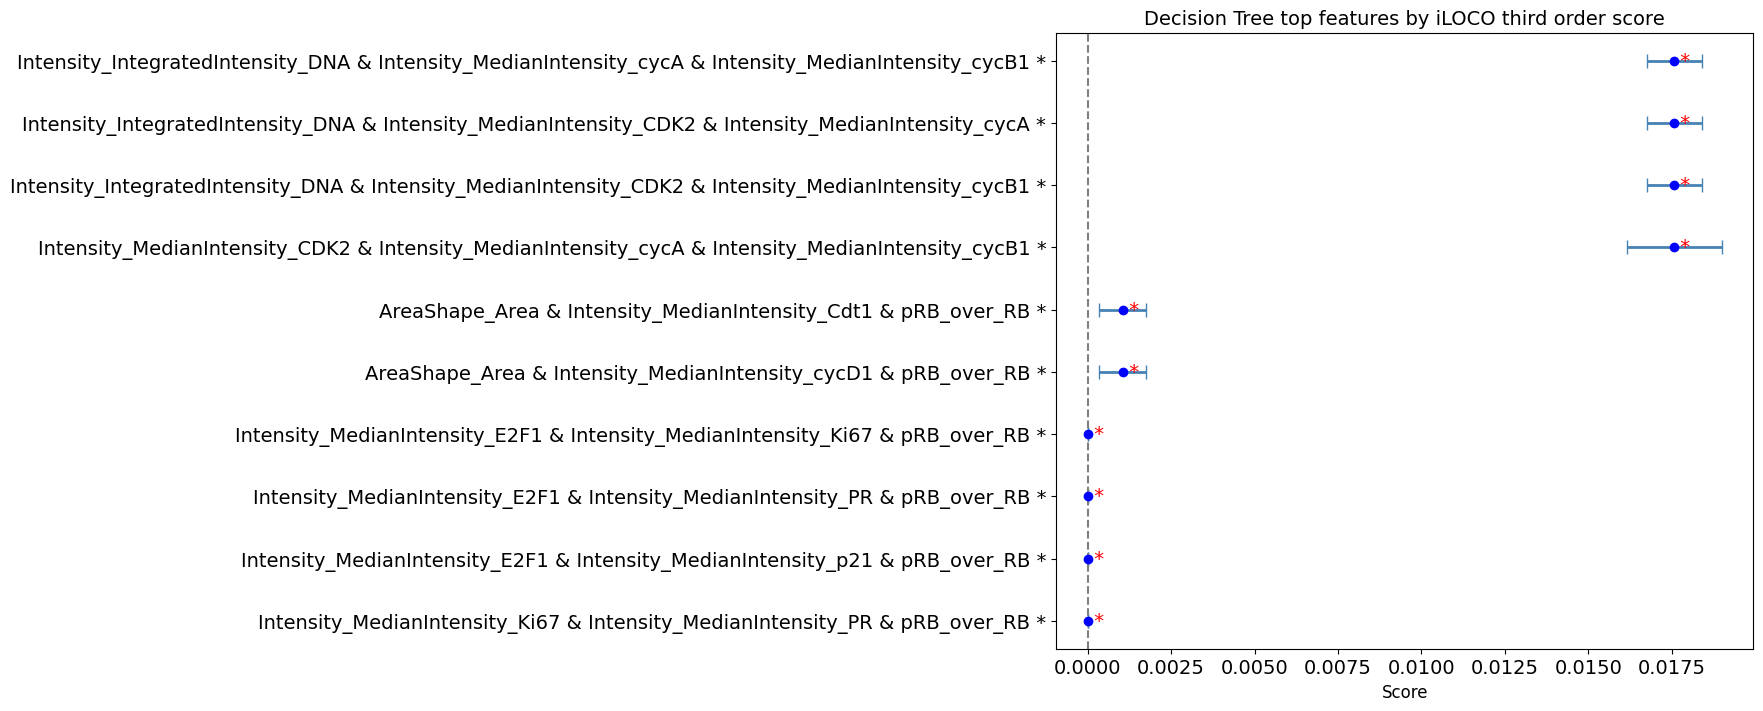

In [16]:
# Plot
top_20 = df.nlargest(10, "scores")
# Copy feature names so we can modify them without affecting the original DataFrame
ytick_labels = top_20["feature"].copy()

# Add star next to feature names if CI does not include zero
for i, (score, ci) in enumerate(zip(top_20["scores"], top_20["ci"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:
        ytick_labels.iloc[i] += " *"

plt.figure(figsize=(9, 8))
plt.errorbar(
    top_20["scores"],
    top_20["feature"],
    xerr=top_20["ci"],
    fmt='o',  # Point marker
    color='blue',
    ecolor='steelblue',
    elinewidth=2,
    capsize=5
)
plt.axvline(x=0, color='gray', linestyle='--')
plt.xticks(fontsize=14)  # Rotate x-axis labels vertically
plt.xlabel("Score", fontsize=12)
plt.title("Decision Tree top features by iLOCO third order score", fontsize=14)

# Add stars for scores whose confidence intervals do not include 0
for i, (score, ci, feature) in enumerate(zip(top_20["scores"], top_20["ci"], top_20["feature"])):
    lower = score - ci
    upper = score + ci
    if lower > 0 or upper < 0:  # CI does not include 0
        plt.text(score, feature, " *", color='red', fontsize=14, va='center')

plt.yticks(ticks=top_20["feature"], labels=ytick_labels, fontsize=14)

plt.gca().invert_yaxis()  # Reverse y-axis

plt.tight_layout()
plt.show()